# CardioIA — Exploração Inicial (Fase 1)

Ponto de partida para as fases seguintes. Carrega as três bases e
confere que estão íntegras. Análise aprofundada e modelagem são das
próximas fases — aqui só validamos que os dados carregam.


In [1]:
import pathlib
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path('fase1')
NUMERICO = RAIZ / 'data' / 'numerico'
print(RAIZ.resolve())


C:\Users\VictorRolim\source\repos\CardioIA\fase1


## Parte 1 — dados numéricos


In [2]:
clinico = pd.read_csv(NUMERICO / 'heart_disease_clinico.csv')
print(clinico.shape)
clinico.head()


(920, 17)


,paciente_id,origem_base,idade,sexo,tipo_dor_toracica,pressao_repouso_mmhg,colesterol_mgdl,glicemia_jejum_alta,ecg_repouso,fc_maxima_bpm,angina_exercicio,depressao_st_oldpeak,inclinacao_st,n_vasos_obstruidos,talassemia,num_diagnostico,doenca_cardiaca
0,cleveland-001,cleveland,63,masculino,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,cleveland-002,cleveland,67,masculino,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,cleveland-003,cleveland,67,masculino,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,cleveland-004,cleveland,37,masculino,3,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,cleveland-005,cleveland,41,feminino,2,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
iot = pd.read_csv(NUMERICO / 'iot_wearable_telemetria.csv')
print(iot.shape)
iot.head()


(6440, 11)


,paciente_id,data,fc_repouso_bpm,fc_media_bpm,hrv_ms,spo2_pct,pas_mmhg,pad_mmhg,passos,minutos_atividade,alerta_arritmia
0,cleveland-001,2026-08-01,64.4,71.7,43.9,98.3,134.5,81.7,4496,41,0
1,cleveland-001,2026-08-02,59.8,73.9,59.2,98.3,126.6,84.3,7681,65,0
2,cleveland-001,2026-08-03,66.7,77.1,51.8,97.3,119.9,81.2,6561,57,0
3,cleveland-001,2026-08-04,64.7,76.3,55.5,97.9,145.3,98.4,5917,49,0
4,cleveland-001,2026-08-05,62.7,76.8,45.5,96.7,131.9,83.7,7817,67,0


In [4]:
# prevalência por centro — base da análise de viés em docs/VIESES.md
(clinico.groupby('origem_base')['doenca_cardiaca'].agg(['mean', 'count']) * [100, 1]).round(1)


,mean,count
origem_base,,
cleveland,45.9,303
hungarian,36.1,294
switzerland,93.5,123
va,74.5,200


## Parte 2 — textos


In [5]:
for arquivo in sorted((RAIZ / 'docs' / 'textos').glob('*.txt')):
    corpo = arquivo.read_text(encoding='utf-8').split('=== FIM PROCEDENCIA ===')[1]
    print(f'{arquivo.name:38s} {len(corpo.split()):>7d} palavras')


01_scielo_mortalidade_dcv.txt             5786 palavras
02_sbc_diretriz_hipertensao.txt          70213 palavras
03_opas_dcv_divulgacao.txt                1704 palavras


## Parte 3 — imagens


In [6]:
manifest = pd.read_csv(RAIZ / 'assets' / 'imagens' / 'MANIFEST.csv')
print(manifest['classe'].value_counts().to_string())
manifest.head()


classe
arritmia             30
historico_infarto    30
infarto              30
normal               30


,arquivo,classe,arquivo_origem,url_origem,sha256,largura,altura,bytes
0,arritmia_001.jpg,arritmia,HB(83).jpg,https://data.mendeley.com/public-files/dataset...,da123fecf00a357778b52d9b90ec6b9ed117246f4e6a97...,1024,727,177183
1,arritmia_002.jpg,arritmia,HB(66).jpg,https://data.mendeley.com/public-files/dataset...,113545f8dd2651ee13e0c1fc1ce5f005903cbc048d5390...,1024,727,175975
2,arritmia_003.jpg,arritmia,HB(68).jpg,https://data.mendeley.com/public-files/dataset...,a336ff0e46d2209354814e0d53d69411f0a07ef04e2458...,1024,727,175110
3,arritmia_004.jpg,arritmia,HB(111).jpg,https://data.mendeley.com/public-files/dataset...,4a305e331b4490fe4632b0b05ecf21a471d6220ea4e16e...,1024,727,178747
4,arritmia_005.jpg,arritmia,HB(151).jpg,https://data.mendeley.com/public-files/dataset...,20955429bd7ac9f0bef7509cd28d016e34d716d4820cdc...,1024,727,181209


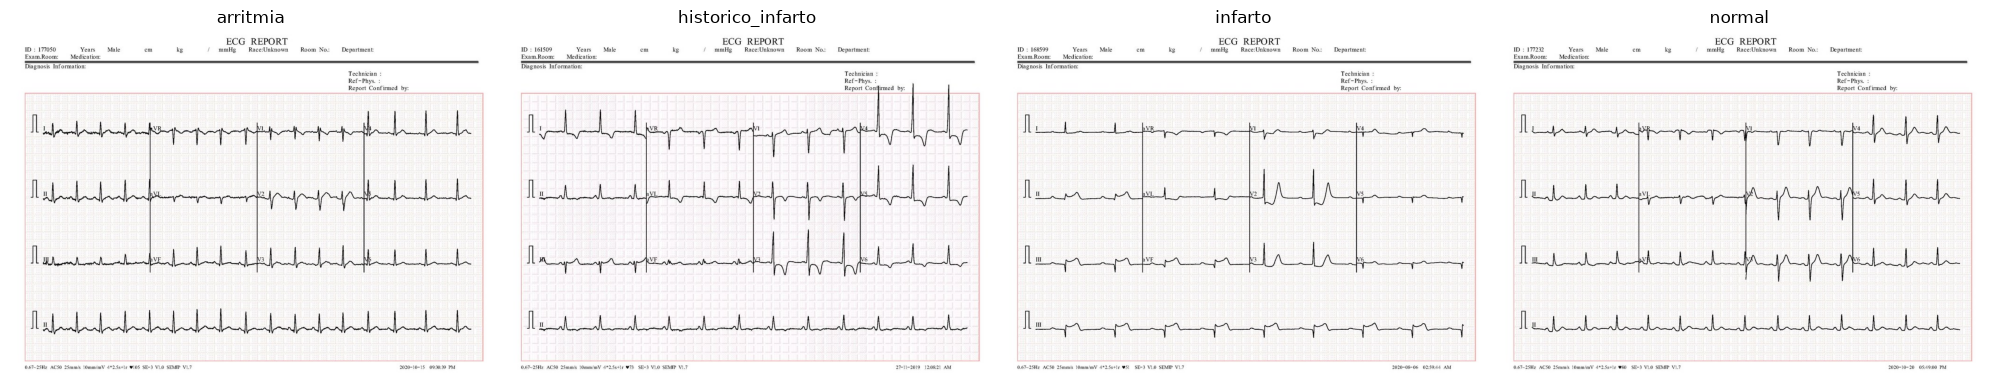

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

amostra = manifest.groupby('classe').head(1)
fig, eixos = plt.subplots(1, len(amostra), figsize=(20, 6))
for eixo, linha in zip(eixos, amostra.itertuples(index=False)):
    eixo.imshow(Image.open(RAIZ / 'assets' / 'imagens' / linha.arquivo))
    eixo.set_title(linha.classe)
    eixo.axis('off')
plt.tight_layout()
